# TravelTide Customer Perk Recommendation Analysis

## Business Problem

TravelTide wants to increase customer engagement and retention by offering personalized travel perks.

The objective of this project is to analyze customer behavior, identify travel preferences, and recommend the most relevant perk for each customer.

Possible perks include:

- Flight Discount Voucher
- Hotel Discount Voucher
- Free Checked Bag
- Hotel Night Discount

## Success Criteria

- Build a customer-level analytical dataset
- Analyze customer travel behavior
- Develop a rule-based recommendation framework
- Validate recommendation quality
- Create Tableau dashboards for business stakeholders

# Data Extraction

Data was extracted from the TravelTide PostgreSQL database using SQL.

Source tables:

- users
- sessions
- flights
- hotels

Customer-level features were created by aggregating booking activity, browsing behavior, discount usage, baggage behavior, hotel stay patterns, and demographic information.

In [175]:
# Import required libraries

import pandas as pd
import numpy as np

In [176]:
# Load customer-level dataset generated from SQL extraction

df = pd.read_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/customer_features.csv"
)

print(df.shape)

(50000, 14)


# Data Quality Assessment

Before building recommendation logic, data quality was assessed to identify:

- Missing values
- Invalid values
- Aggregation issues
- Feature completeness

In [177]:
# Check dataset dimensions

df.shape

(50000, 14)

In [178]:
# Review missing values across all columns

df.isnull().sum()

,0
user_id,0
age,0
gender,0
married,0
has_children,0
total_sessions,0
total_flights,0
total_hotels,0
avg_page_clicks,0
flight_discount_prop,0


In [179]:
# Identify negative hotel-night values

(df["avg_nights"] < 0).sum()

np.int64(90)

## Missing Value Treatment

Observations:

- total_bags contained null values for customers without flights
- avg_nights contained null values for customers without hotel bookings

These values were replaced with zero because the absence of flights or hotels naturally implies no bags or hotel nights.

In [180]:
# Replace null values with business-appropriate defaults

df["total_bags"] = df["total_bags"].fillna(0)

df["avg_nights"] = df["avg_nights"].fillna(0)

In [181]:
# Confirm all missing values have been resolved

df.isnull().sum()

,0
user_id,0
age,0
gender,0
married,0
has_children,0
total_sessions,0
total_flights,0
total_hotels,0
avg_page_clicks,0
flight_discount_prop,0


In [182]:
# Save cleaned analytical dataset

df.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/customer_features_clean.csv",
    index=False
)

# Exploratory Data Analysis

The goal of EDA is to understand customer demographics, booking behavior, travel habits, and discount usage patterns before designing a recommendation strategy.

In [183]:
# Gender distribution

df["gender"].value_counts(normalize=True)

,proportion
gender,
M,0.54442
F,0.44688
O,0.00870


In [184]:
# Marital status distribution

df["married"].value_counts(normalize=True)

,proportion
married,
False,0.61174
True,0.38826


In [185]:
# Children status distribution

df["has_children"].value_counts(normalize=True)

,proportion
has_children,
False,0.68404
True,0.31596


In [186]:
# Review feature distributions

df[[
    "total_bags",
    "avg_nights",
    "total_flights",
    "flight_discount_prop",
    "hotel_discount_prop"
]].quantile([0.25, 0.50, 0.75, 0.90])

,total_bags,avg_nights,total_flights,flight_discount_prop,hotel_discount_prop
0.25,0.0,1.000000,1.0,0.000000,0.000
0.50,1.0,3.000000,2.0,0.166667,0.125
0.75,2.0,5.000000,3.0,0.285714,0.250
0.90,3.0,8.666667,4.0,0.428571,0.375


# Feature Engineering

To compare different perk types fairly, behavioral features were transformed into normalized scores.

The goal is to identify the perk most aligned with each customer's demonstrated travel behavior.

In [187]:
# Normalize flight discount usage

df["flight_score"] = (
    df["flight_discount_prop"] /
    df["flight_discount_prop"].max()
)

# Normalize hotel discount usage

df["hotel_score"] = (
    df["hotel_discount_prop"] /
    df["hotel_discount_prop"].max()
)

# Normalize baggage behavior

df["bag_score_norm"] = (
    df["total_bags"] /
    df["total_bags"].max()
)

# Normalize hotel-night behavior

df["night_score"] = (
    df["avg_nights"] /
    df["avg_nights"].max()
)

# Recommendation Framework

A rule-based recommendation framework was chosen because:

- Transparent
- Explainable
- Easy for business stakeholders to understand
- Appropriate for available customer behavior signals

Each customer is assigned the perk corresponding to their strongest normalized behavioral preference.

In [188]:
def assign_perk_final(row):

    scores = {
        "Flight Discount Voucher": row["flight_score"],
        "Hotel Discount Voucher": row["hotel_score"],
        "Free Checked Bag": row["bag_score_norm"],
        "Hotel Night Discount": row["night_score"]
    }

    return max(scores, key=scores.get)

df["favorite_perk_final"] = df.apply(
    assign_perk_final,
    axis=1
)

# Recommendation Validation

Recommendations were validated by comparing the average behavior of customers assigned to each perk group.

A successful recommendation framework should assign perks to customers whose observed behavior aligns with the perk they received.

In [189]:
df["favorite_perk_final"].value_counts()

,count
favorite_perk_final,
Flight Discount Voucher,26008
Hotel Discount Voucher,10945
Hotel Night Discount,7050
Free Checked Bag,5997


In [190]:
df.groupby("favorite_perk_final")[
[
    "total_flights",
    "total_hotels",
    "total_bags",
    "avg_nights",
    "flight_discount_prop",
    "hotel_discount_prop"
]
].mean().round(2)

,total_flights,total_hotels,total_bags,avg_nights,flight_discount_prop,hotel_discount_prop
favorite_perk_final,,,,,,
Flight Discount Voucher,2.04,2.01,1.15,3.29,0.30,0.12
Free Checked Bag,2.96,2.63,2.98,2.51,0.05,0.04
Hotel Discount Voucher,2.20,2.22,1.27,3.62,0.07,0.35
Hotel Night Discount,1.47,1.77,0.65,7.35,0.03,0.03


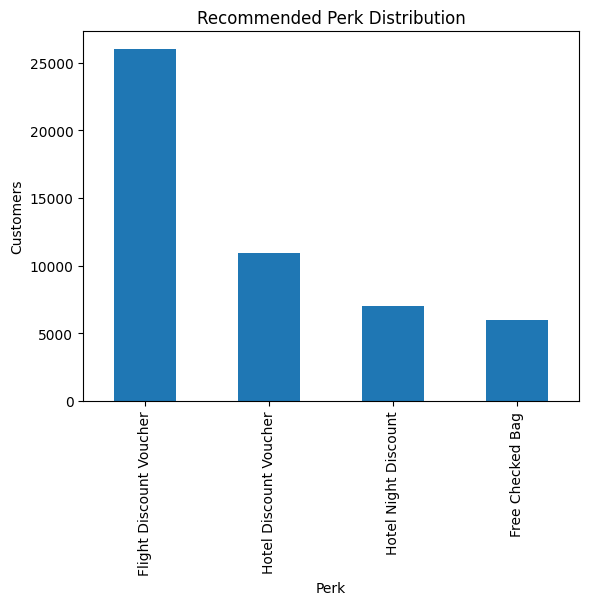

In [191]:
import matplotlib.pyplot as plt

df["favorite_perk_final"].value_counts().plot(
    kind="bar"
)

plt.title("Recommended Perk Distribution")
plt.xlabel("Perk")
plt.ylabel("Customers")
plt.show()

# Dashboard Dataset Creation

A final Tableau-ready dataset was created containing:

- Customer demographics
- Travel behavior
- Engineered features
- Recommended perk

This dataset serves as the single source of truth for dashboard development.

In [192]:
dashboard_df = df.copy()

dashboard_df.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/dashboard_final.csv",
    index=False
)

print(dashboard_df.shape)

(50000, 19)


# Conclusions

Key findings:

- Flight discount sensitivity is the strongest customer preference signal.
- Hotel discount usage identifies a distinct customer segment.
- Customers with high baggage counts benefit most from free checked bags.
- Customers with longer hotel stays are strong candidates for hotel-night rewards.

Business Impact:

- Personalized perks can increase customer engagement.
- Recommendations are transparent and explainable.
- The framework can be operationalized with minimal complexity.
- Tableau dashboards enable ongoing monitoring and optimization.

In [193]:
print(df.shape)

df.head()

(50000, 19)


,user_id,age,gender,married,has_children,total_sessions,total_flights,total_hotels,avg_page_clicks,flight_discount_prop,hotel_discount_prop,total_bags,avg_nights,cancellations,flight_score,hotel_score,bag_score_norm,night_score,favorite_perk_final
0,174416,46,M,True,False,7,1,3,15.857143,0.142857,0.428571,1.0,8.333333,0,0.142857,0.428571,0.05,0.170068,Hotel Discount Voucher
1,157393,44,F,True,False,6,5,3,20.333333,0.000000,0.000000,2.0,5.000000,0,0.000000,0.000000,0.10,0.102041,Hotel Night Discount
2,800467,58,M,True,False,4,2,3,17.500000,0.000000,0.500000,1.0,4.666667,0,0.000000,0.500000,0.05,0.095238,Hotel Discount Voucher
3,216468,52,M,True,True,6,3,3,19.500000,0.000000,0.166667,2.0,2.000000,0,0.000000,0.166667,0.10,0.040816,Hotel Discount Voucher
4,545641,40,M,False,False,5,4,5,19.600000,0.600000,0.400000,1.0,3.400000,0,0.600000,0.400000,0.05,0.069388,Flight Discount Voucher


Playground queries

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               50000 non-null  int64  
 1   age                   50000 non-null  int64  
 2   gender                50000 non-null  object 
 3   married               50000 non-null  bool   
 4   has_children          50000 non-null  bool   
 5   total_sessions        50000 non-null  int64  
 6   total_flights         50000 non-null  int64  
 7   total_hotels          50000 non-null  int64  
 8   avg_page_clicks       50000 non-null  float64
 9   flight_discount_prop  50000 non-null  float64
 10  hotel_discount_prop   50000 non-null  float64
 11  total_bags            50000 non-null  float64
 12  avg_nights            50000 non-null  float64
 13  cancellations         50000 non-null  int64  
 14  flight_score          50000 non-null  float64
 15  hotel_score        

In [195]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0


In [196]:
df["avg_nights"] = df["avg_nights"].fillna(0)

df["total_bags"] = df["total_bags"].fillna(0)

df.isnull().sum()

,0
user_id,0
age,0
gender,0
married,0
has_children,0
total_sessions,0
total_flights,0
total_hotels,0
avg_page_clicks,0
flight_discount_prop,0


In [197]:
df["avg_nights"] = df["avg_nights"].fillna(0)
df["total_bags"] = df["total_bags"].fillna(0)

df.describe()

,user_id,age,total_sessions,total_flights,total_hotels,avg_page_clicks,flight_discount_prop,hotel_discount_prop,total_bags,avg_nights,cancellations,flight_score,hotel_score,bag_score_norm,night_score
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,4.980526e+05,42.840640,5.388520,2.105320,2.094120,19.647452,0.182788,0.147285,1.323800,3.840772,0.095580,0.182788,0.147285,0.066190,0.078383
std,2.921745e+05,12.476103,2.454802,1.484261,1.502127,16.232732,0.194397,0.180268,1.518552,3.839880,0.302004,0.194397,0.180268,0.075928,0.078365
min,1.800000e+01,19.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,-0.040816
25%,2.441835e+05,34.000000,4.000000,1.000000,1.000000,13.222222,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.020408
50%,4.939175e+05,43.000000,5.000000,2.000000,2.000000,17.000000,0.166667,0.125000,1.000000,3.000000,0.000000,0.166667,0.125000,0.050000,0.061224
75%,7.477495e+05,51.000000,7.000000,3.000000,3.000000,21.833333,0.285714,0.250000,2.000000,5.000000,0.000000,0.285714,0.250000,0.100000,0.102041
max,1.020869e+06,92.000000,16.000000,11.000000,11.000000,2421.000000,1.000000,1.000000,20.000000,49.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [198]:
# Fix invalid hotel stays (negative stay value)

df.loc[df["avg_nights"] < 0, "avg_nights"] = 0

# Verify

df["avg_nights"].describe()

,avg_nights
count,50000.000000
mean,3.842432
std,3.838007
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,49.000000


In [199]:
# Understanding Distributions - session
df["total_sessions"].describe()

,total_sessions
count,50000.000000
mean,5.388520
std,2.454802
min,1.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,16.000000


In [200]:
# Understanding Distributions - flights

df["total_flights"].describe()

,total_flights
count,50000.000000
mean,2.105320
std,1.484261
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,11.000000


In [201]:
# Understanding Distributions - hotels
df["total_hotels"].describe()

,total_hotels
count,50000.000000
mean,2.094120
std,1.502127
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,11.000000


In [202]:
# Understanding Distributions - bags
df["total_bags"].describe()

,total_bags
count,50000.000000
mean,1.323800
std,1.518552
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,20.000000


In [203]:
# Understanding Distributions - nights
df["avg_nights"].describe()

,avg_nights
count,50000.000000
mean,3.842432
std,3.838007
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,49.000000


In [204]:
# Understanding Distributions - Discount Sensitivity for flights
df["flight_discount_prop"].describe()

,flight_discount_prop
count,50000.000000
mean,0.182788
std,0.194397
min,0.000000
25%,0.000000
50%,0.166667
75%,0.285714
max,1.000000


In [205]:
# Understanding Distributions - Discount Sensitivity for hotels
df["hotel_discount_prop"].describe()

,hotel_discount_prop
count,50000.000000
mean,0.147285
std,0.180268
min,0.000000
25%,0.000000
50%,0.125000
75%,0.250000
max,1.000000


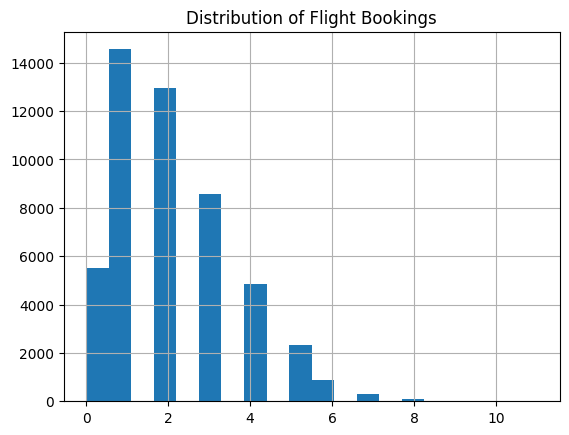

In [206]:
# Distribution of Flight Bookings
import matplotlib.pyplot as plt

df["total_flights"].hist(bins=20)

plt.title("Distribution of Flight Bookings")

plt.show()

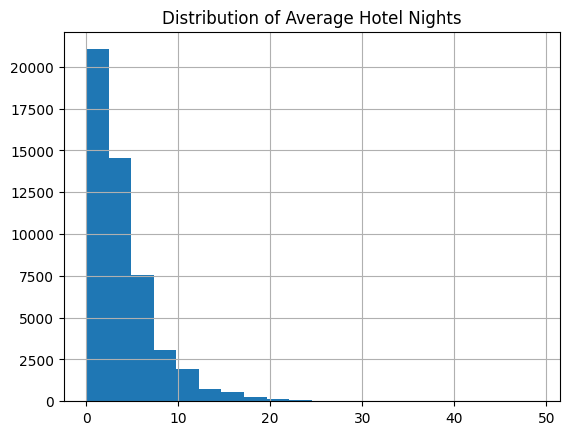

In [207]:
#Distribution of Average Hotel Nights

df["avg_nights"].hist(bins=20)

plt.title("Distribution of Average Hotel Nights")

plt.show()

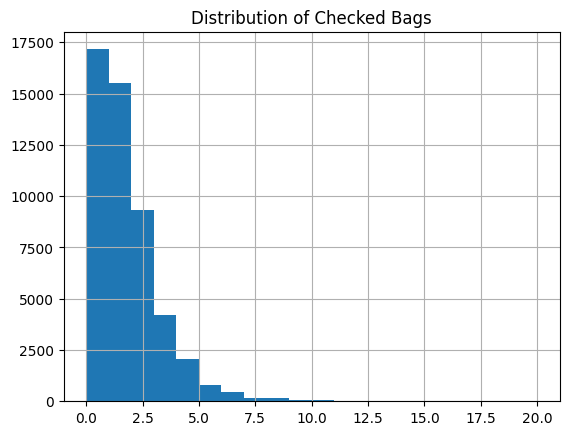

In [208]:
#Distribution of Checked Bags
df["total_bags"].hist(bins=20)

plt.title("Distribution of Checked Bags")

plt.show()

In [209]:
(df["avg_nights"] < 0).sum()

np.int64(0)

In [210]:
# identifying Null Values
df.isnull().sum()

,0
user_id,0
age,0
gender,0
married,0
has_children,0
total_sessions,0
total_flights,0
total_hotels,0
avg_page_clicks,0
flight_discount_prop,0


In [211]:
# df["user_id"].min()
df["user_id"].max()

1020869

In [212]:
df["gender"].value_counts(normalize=True)

,proportion
gender,
M,0.54442
F,0.44688
O,0.00870


In [213]:
df["married"].value_counts(normalize=True)

,proportion
married,
False,0.61174
True,0.38826


In [214]:
df["has_children"].value_counts(normalize=True)

,proportion
has_children,
False,0.68404
True,0.31596


In [215]:
#Calculate Percentiles
df[[
    "total_bags",
    "avg_nights",
    "total_flights",
    "flight_discount_prop",
    "hotel_discount_prop"
]].quantile([0.25, 0.50, 0.75, 0.90])

,total_bags,avg_nights,total_flights,flight_discount_prop,hotel_discount_prop
0.25,0.0,1.000000,1.0,0.000000,0.000
0.50,1.0,3.000000,2.0,0.166667,0.125
0.75,2.0,5.000000,3.0,0.285714,0.250
0.90,3.0,8.666667,4.0,0.428571,0.375


In [216]:
# Customers with no flights but missing bags
df[
    (df["total_flights"] == 0) &
    (df["total_bags"].isnull())
].shape

(0, 19)

In [217]:
# Customers with no hotels but missing nights
df[
    (df["total_hotels"] == 0) &
    (df["avg_nights"].isnull())
].shape

(0, 19)

In [218]:
df["total_bags"] = df["total_bags"].fillna(0)
df["avg_nights"] = df["avg_nights"].fillna(0)

df.isnull().sum()

,0
user_id,0
age,0
gender,0
married,0
has_children,0
total_sessions,0
total_flights,0
total_hotels,0
avg_page_clicks,0
flight_discount_prop,0


In [219]:
df.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/customer_features_clean.csv",
    index=False
)

In [220]:
# Customers with no flights but missing bags
df[
    (df["total_flights"] == 0) &
    (df["total_bags"].isnull())
].shape

(0, 19)

In [221]:
# Customers with no hotels but missing nights
df[
    (df["total_hotels"] == 0) &
    (df["avg_nights"].isnull())
].shape

(0, 19)

In [222]:
df.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/customer_features_clean.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [223]:
df[[
    "total_bags",
    "avg_nights",
    "total_flights",
    "flight_discount_prop",
    "hotel_discount_prop"
]].quantile([0.25, 0.50, 0.75, 0.90])

,total_bags,avg_nights,total_flights,flight_discount_prop,hotel_discount_prop
0.25,0.0,1.000000,1.0,0.000000,0.000
0.50,1.0,3.000000,2.0,0.166667,0.125
0.75,2.0,5.000000,3.0,0.285714,0.250
0.90,3.0,8.666667,4.0,0.428571,0.375


In [224]:
# creating - Perk Scores

df["bag_score"] = df["total_bags"]

df["hotel_night_score"] = df["avg_nights"]

df["flight_discount_score"] = (
    df["flight_discount_prop"] *
    df["total_flights"]
)

df["hotel_discount_score"] = (
    df["hotel_discount_prop"] *
    df["total_hotels"]
)

In [225]:
# assigning favourite perks
perk_columns = [
    "bag_score",
    "hotel_night_score",
    "flight_discount_score",
    "hotel_discount_score"
]

perk_mapping = {
    "bag_score": "Free Checked Bag",
    "hotel_night_score": "Hotel Night Discount",
    "flight_discount_score": "Flight Discount Voucher",
    "hotel_discount_score": "Hotel Discount Voucher"
}

df["favorite_perk"] = (
    df[perk_columns]
    .idxmax(axis=1)
    .map(perk_mapping)
)

In [226]:
#validating results
df["favorite_perk"].value_counts()

,count
favorite_perk,
Hotel Night Discount,33140
Free Checked Bag,15529
Flight Discount Voucher,1165
Hotel Discount Voucher,166


RESULT AFTER CREARTING PERKS
results are biased towards "hotel nights" using the current scoring formula thus creating a scale problem. Even a highly discount-sensitive traveler loses to a moderate hotel-stay customer. Hence, the model is biased toward hotel nights.

The aim recommendation engine should create meaningful differentiation. So,instead of comparing raw values, compare relative strength - taking a Normalize Scores approach as normalization puts every score onto the same 0–1 scale.

In [227]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_cols = [
    "bag_score",
    "hotel_night_score",
    "flight_discount_score",
    "hotel_discount_score"
]

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[score_cols]),
    columns=score_cols
)

df_scaled.head()

,bag_score,hotel_night_score,flight_discount_score,hotel_discount_score
0,0.05,0.170068,0.030612,0.321429
1,0.10,0.102041,0.000000,0.000000
2,0.05,0.095238,0.000000,0.375000
3,0.10,0.040816,0.000000,0.125000
4,0.05,0.069388,0.514286,0.500000


In [228]:
#replacing the assignment logic
perk_mapping = {
    "bag_score": "Free Checked Bag",
    "hotel_night_score": "Hotel Night Discount",
    "flight_discount_score": "Flight Discount Voucher",
    "hotel_discount_score": "Hotel Discount Voucher"
}

df["favorite_perk_v2"] = (
    df_scaled
    .idxmax(axis=1)
    .map(perk_mapping)
)

In [229]:
df["favorite_perk_v2"].value_counts()

,count
favorite_perk_v2,
Free Checked Bag,12969
Hotel Night Discount,12861
Flight Discount Voucher,12558
Hotel Discount Voucher,11612


In [230]:
#Validating the normilisation formula
df.groupby("favorite_perk_v2")[
[
    "total_flights",
    "total_hotels",
    "total_bags",
    "avg_nights",
    "flight_discount_prop",
    "hotel_discount_prop"
]
].mean().round(2)

,total_flights,total_hotels,total_bags,avg_nights,flight_discount_prop,hotel_discount_prop
favorite_perk_v2,,,,,,
Flight Discount Voucher,2.74,2.41,1.44,2.74,0.36,0.11
Free Checked Bag,1.78,1.47,1.88,1.59,0.10,0.10
Hotel Discount Voucher,2.61,2.87,1.32,3.62,0.15,0.32
Hotel Night Discount,1.35,1.71,0.66,7.39,0.12,0.08


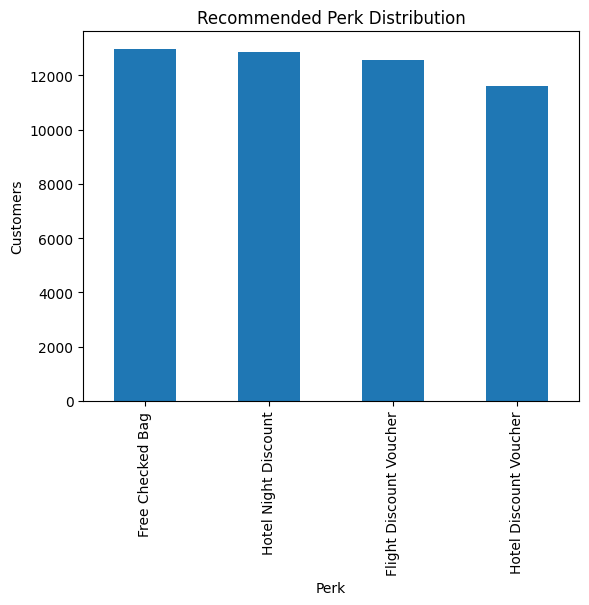

In [231]:
# recommendation perk distribution
import matplotlib.pyplot as plt

df["favorite_perk_v2"].value_counts().plot(
    kind="bar"
)

plt.title("Recommended Perk Distribution")
plt.xlabel("Perk")
plt.ylabel("Customers")
plt.show()

In [232]:
print(df.shape)

(50000, 25)


In [233]:
df.columns.tolist()

['user_id',
 'age',
 'gender',
 'married',
 'has_children',
 'total_sessions',
 'total_flights',
 'total_hotels',
 'avg_page_clicks',
 'flight_discount_prop',
 'hotel_discount_prop',
 'total_bags',
 'avg_nights',
 'cancellations',
 'flight_score',
 'hotel_score',
 'bag_score_norm',
 'night_score',
 'favorite_perk_final',
 'bag_score',
 'hotel_night_score',
 'flight_discount_score',
 'hotel_discount_score',
 'favorite_perk',
 'favorite_perk_v2']

In [234]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [235]:
import os

os.listdir("/content/drive/MyDrive/My Learnings/BI Project Lifecycle")

['Export-imort stat_BI Project Lifecycle.gsheet',
 'BI Project Lifecycle.gdoc',
 'customer_features.csv',
 'customer_features_clean.csv',
 'dashboard_final.csv',
 'dashboard_dataset.csv',
 'travel_tide_customer_perks_analysis.ipynb',
 'travel_tide_customer_perks_analysis_refactored.ipynb']

In [236]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/customer_features_clean.csv"
)

print(df.shape)

(50000, 19)


In [237]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [238]:
import os

os.listdir("/content/drive/MyDrive/My Learnings/BI Project Lifecycle")

['Export-imort stat_BI Project Lifecycle.gsheet',
 'BI Project Lifecycle.gdoc',
 'customer_features.csv',
 'customer_features_clean.csv',
 'dashboard_final.csv',
 'dashboard_dataset.csv',
 'travel_tide_customer_perks_analysis.ipynb',
 'travel_tide_customer_perks_analysis_refactored.ipynb']

In [239]:
df.columns.tolist()

['user_id',
 'age',
 'gender',
 'married',
 'has_children',
 'total_sessions',
 'total_flights',
 'total_hotels',
 'avg_page_clicks',
 'flight_discount_prop',
 'hotel_discount_prop',
 'total_bags',
 'avg_nights',
 'cancellations',
 'flight_score',
 'hotel_score',
 'bag_score_norm',
 'night_score',
 'favorite_perk_final']

In [240]:
#recreating Customer Scores as the previous dataframes were not saved.

# Flight Discount Score
df["flight_discount_score"] = (
    (df["flight_discount_prop"] >= 0.285714).astype(int)
)

# Hotel Discount Score
df["hotel_discount_score"] = (
    (df["hotel_discount_prop"] >= 0.25).astype(int)
)

# Checked Bag Score
df["bag_score"] = (
    (df["total_bags"] >= 2).astype(int)
)

# Hotel Night Score
df["hotel_night_score"] = (
    (df["avg_nights"] >= 5).astype(int)
)

In [241]:
def assign_perk_v2(row):

    scores = {
        "Flight Discount Voucher": row["flight_discount_prop"],
        "Hotel Discount Voucher": row["hotel_discount_prop"],
        "Free Checked Bag": row["total_bags"],
        "Hotel Night Discount": row["avg_nights"]
    }

    return max(scores, key=scores.get)

df["favorite_perk_v2"] = df.apply(assign_perk_v2, axis=1)

In [242]:
df["favorite_perk_v2"].value_counts()

,count
favorite_perk_v2,
Hotel Night Discount,33264
Free Checked Bag,11275
Flight Discount Voucher,4371
Hotel Discount Voucher,1090


In [243]:
def assign_perk_v2(row):

    scores = {
        "Flight Discount Voucher": row["flight_discount_score"],
        "Hotel Discount Voucher": row["hotel_discount_score"],
        "Free Checked Bag": row["bag_score"],
        "Hotel Night Discount": row["hotel_night_score"]
    }

    max_score = max(scores.values())

    top_perks = [
        perk
        for perk, score in scores.items()
        if score == max_score
    ]

    return top_perks[0]

df["favorite_perk_v2"] = df.apply(assign_perk_v2, axis=1)

In [244]:
df["favorite_perk_v2"].value_counts()

,count
favorite_perk_v2,
Flight Discount Voucher,26611
Free Checked Bag,9237
Hotel Discount Voucher,9022
Hotel Night Discount,5130


In [245]:
df.groupby("favorite_perk_v2")[
[
    "flight_discount_score",
    "hotel_discount_score",
    "bag_score",
    "hotel_night_score"
]
].mean()

,flight_discount_score,hotel_discount_score,bag_score,hotel_night_score
favorite_perk_v2,,,,
Flight Discount Voucher,0.514825,0.175604,0.186539,0.163692
Free Checked Bag,0.000000,0.000000,1.000000,0.235250
Hotel Discount Voucher,0.000000,1.000000,0.344270,0.306916
Hotel Night Discount,0.000000,0.000000,0.000000,1.000000


In [246]:
df["flight_score"] = (
    df["flight_discount_prop"] /
    df["flight_discount_prop"].max()
)

df["hotel_score"] = (
    df["hotel_discount_prop"] /
    df["hotel_discount_prop"].max()
)

df["bag_score_norm"] = (
    df["total_bags"] /
    df["total_bags"].max()
)

df["night_score"] = (
    df["avg_nights"] /
    df["avg_nights"].max()
)

In [247]:
def assign_perk_final(row):

    scores = {
        "Flight Discount Voucher": row["flight_score"],
        "Hotel Discount Voucher": row["hotel_score"],
        "Free Checked Bag": row["bag_score_norm"],
        "Hotel Night Discount": row["night_score"]
    }

    return max(scores, key=scores.get)

df["favorite_perk_final"] = df.apply(
    assign_perk_final,
    axis=1
)

In [248]:
df["favorite_perk_final"].value_counts()

,count
favorite_perk_final,
Flight Discount Voucher,26008
Hotel Discount Voucher,10945
Hotel Night Discount,7050
Free Checked Bag,5997


In [249]:
df.groupby("favorite_perk_final")[
[
    "total_flights",
    "total_hotels",
    "total_bags",
    "avg_nights",
    "flight_discount_prop",
    "hotel_discount_prop"
]
].mean().round(2)

,total_flights,total_hotels,total_bags,avg_nights,flight_discount_prop,hotel_discount_prop
favorite_perk_final,,,,,,
Flight Discount Voucher,2.04,2.01,1.15,3.29,0.30,0.12
Free Checked Bag,2.96,2.63,2.98,2.51,0.05,0.04
Hotel Discount Voucher,2.20,2.22,1.27,3.62,0.07,0.35
Hotel Night Discount,1.47,1.77,0.65,7.35,0.03,0.03


In [250]:
dashboard_df = df.copy()

dashboard_df.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/dashboard_dataset.csv",
    index=False
)

print(dashboard_df.shape)

(50000, 24)


In [251]:
dashboard_df.columns.tolist()

['user_id',
 'age',
 'gender',
 'married',
 'has_children',
 'total_sessions',
 'total_flights',
 'total_hotels',
 'avg_page_clicks',
 'flight_discount_prop',
 'hotel_discount_prop',
 'total_bags',
 'avg_nights',
 'cancellations',
 'flight_score',
 'hotel_score',
 'bag_score_norm',
 'night_score',
 'favorite_perk_final',
 'flight_discount_score',
 'hotel_discount_score',
 'bag_score',
 'hotel_night_score',
 'favorite_perk_v2']

In [252]:
dashboard_final = dashboard_df[
[
    "user_id",
    "age",
    "gender",
    "married",
    "has_children",
    "total_sessions",
    "total_flights",
    "total_hotels",
    "avg_page_clicks",
    "flight_discount_prop",
    "hotel_discount_prop",
    "total_bags",
    "avg_nights",
    "cancellations",
    "favorite_perk_final"
]
]

In [253]:
dashboard_final.shape

(50000, 15)

In [254]:
dashboard_final.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/dashboard_final.csv",
    index=False
)

In [255]:
import os

os.listdir(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle"
)

['Export-imort stat_BI Project Lifecycle.gsheet',
 'BI Project Lifecycle.gdoc',
 'customer_features.csv',
 'customer_features_clean.csv',
 'dashboard_final.csv',
 'dashboard_dataset.csv',
 'travel_tide_customer_perks_analysis.ipynb',
 'travel_tide_customer_perks_analysis_refactored.ipynb']

In [256]:
print(df.shape)

df.columns.tolist()

(50000, 24)


['user_id',
 'age',
 'gender',
 'married',
 'has_children',
 'total_sessions',
 'total_flights',
 'total_hotels',
 'avg_page_clicks',
 'flight_discount_prop',
 'hotel_discount_prop',
 'total_bags',
 'avg_nights',
 'cancellations',
 'flight_score',
 'hotel_score',
 'bag_score_norm',
 'night_score',
 'favorite_perk_final',
 'flight_discount_score',
 'hotel_discount_score',
 'bag_score',
 'hotel_night_score',
 'favorite_perk_v2']

In [257]:
dashboard_final = df[
[
    "user_id",
    "age",
    "gender",
    "married",
    "has_children",
    "total_sessions",
    "total_flights",
    "total_hotels",
    "avg_page_clicks",
    "flight_discount_prop",
    "hotel_discount_prop",
    "total_bags",
    "avg_nights",
    "cancellations",
    "flight_score",
    "hotel_score",
    "bag_score_norm",
    "night_score",
    "favorite_perk_final"
]
]

dashboard_final.shape

(50000, 19)

In [259]:
dashboard_final.to_csv(
    "/content/drive/MyDrive/My Learnings/BI Project Lifecycle/dashboard_final.csv",
    index=False
)